# Experiment 1: Learning to Grow

> Conducting the first experiment which involves training the cellular automaton to evolve from an initial seed to the desired shape

In [ ]:
#| default_exp learning_to_grow

In [1]:
#| export
from NeuralCellularAutomata_PyTorch.core import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
initial_image_path = 'images/img2.png'

path = 'images/emoji_u1f98e.png'

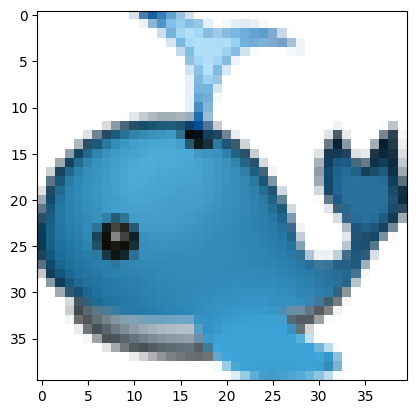

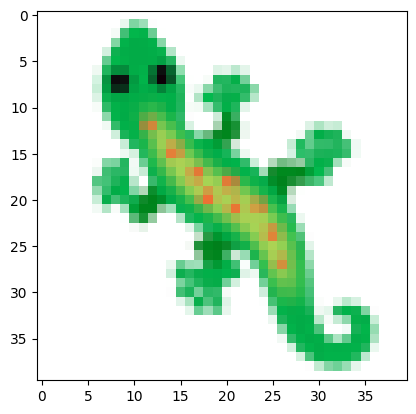

In [8]:
first_image_tensor = load_image(initial_image_path)
img_tensor = load_image(path)

In [9]:
first_image_tensor.shape

torch.Size([1, 4, 40, 40])

In [10]:
img_tensor.shape

torch.Size([1, 4, 40, 40])

# Create a starting seed

Create a grid of shape `1, 16, H, W` initialized with zeros, where all elements are set to 0.

Then, copy the input image tensor into the first 4 channels (RGBA) of this grid.

In [11]:
#| export
seed = torch.zeros(1, 16, TARGET_SIZE, TARGET_SIZE).to(def_device)
seed[0, :4, :, :] = first_image_tensor

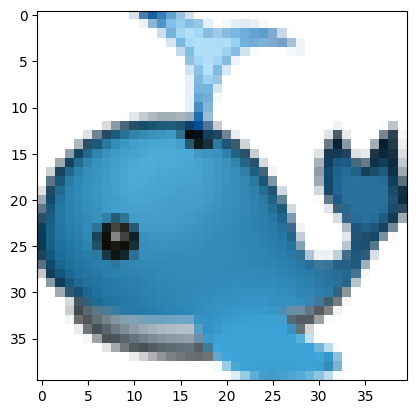

In [12]:
plt.imshow(seed[0, :4].detach().cpu().permute(1, 2, 0))
plt.show()

# Training Loop

In [13]:
#|eval: false


# training hyperparameters 
n_epochs = 8000
batch_size = 8

lr = 2e-3
lr_gamma = 0.9999
betas = (0.5, 0.5)

In [14]:
#|eval: false

# initialize the model
ca = CAModel(CHANNEL_N).to(def_device)

Loading locally saved model

In [19]:
ca.load_state_dict(torch.load('models/ca_model_from_image.pth', map_location=def_device))
ca.eval()

CAModel(
  (brain): Sequential(
    (0): Conv2d(48, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)

In [15]:
#|eval: false


# optimization
import torch.optim as optim

optimizer = torch.optim.Adam(ca.parameters(), lr=lr, betas=betas)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, lr_gamma)

In [16]:
#|eval: false


# create the input to the network and the target
model_in = seed.repeat(batch_size, 1, 1, 1)
target = img_tensor.repeat(batch_size, 1, 1, 1)

In [17]:
model_in.shape

torch.Size([8, 16, 40, 40])

In [18]:
target.shape

torch.Size([8, 4, 40, 40])

In [14]:
#|eval: false


for i in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    steps = torch.randint(64, 96, (1,)).item()
    res = ca(model_in, steps=steps)

    loss = F.mse_loss(res[:, :4], target) # we only care about the RGBA channels
    if i%500 == 0:
        print(f"Epoch: {i} Loss: {loss.item()}")
    loss.backward()
    optimizer.step()
    scheduler.step()

  0%|          | 0/8000 [00:00<?, ?it/s]

Epoch: 0 Loss: 0.18502110242843628


  6%|▋         | 500/8000 [22:32<4:55:20,  2.36s/it]

Epoch: 500 Loss: 0.004343832843005657


 12%|█▎        | 1000/8000 [43:47<5:05:50,  2.62s/it]

...

 88%|████████▊ | 7000/8000 [4:55:14<43:31,  2.61s/it]  

Epoch: 7000 Loss: 7.759056461509317e-05


 94%|█████████▍| 7500/8000 [5:16:09<22:11,  2.66s/it]

Epoch: 7500 Loss: 7.202470442280173e-05


100%|██████████| 8000/8000 [5:36:58<00:00,  2.53s/it]


Saving locally the model

In [16]:
torch.save(ca.state_dict(), 'ca_model_from_image.pth')

Test the training process of the network by generating and displaying an animation.

In [20]:
#|eval: false


images = ca.grow_animation(seed, 200)
display_animation(images)